# Does "doing well by doing good" actually pay? 🌱
### ESG investing vs the plain index — a decade (and two decades) of real money, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Growth/quality tilt: Confirmed](https://img.shields.io/badge/Growth%2Fquality_tilt%3F-Confirmed-8b949e?style=flat-square)

ESG funds are pitched two opposite ways: **"good companies are better-run companies, so ESG investing should outperform"** — or, the skeptic's version, **"you're paying an insurance premium and cutting your universe, so ESG investing should cost you."** Both stories sound plausible. Only one tape can settle it.

We test the two flagship US large-cap ESG ETFs — **ESGU** (since 2016) and **SUSA** (since 2005, the older and more selective one) — against their plain S&P 500 benchmarks (SPY and IVV), for as long as each has existed.

> 📓 **Plain-language layer.** Want the *t*-stats, the factor regression and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Total-return (dividend-reinvested) daily closes, yfinance, as-of 2026-06-30. No survivorship: every ticker here is a single, currently-traded ETF over its own full history. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from esg_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    tapes = data.load_real()
    rets = {t: st.daily_returns(tapes[t]["Close"]) for t in data.TICKERS if t != "^IRX"}
    rf = st.rf_daily(tapes["^IRX"]["Close"].reindex(rets["SPY"].index).ffill())
    gv_spread = rets["IVW"] - rets["IVE"]
else:
    rets = rf = gv_spread = None
print("real cache present:", HAVE_REAL,
      "| ESGU days:", (0 if rets is None else len(rets["ESGU"])),
      "| SUSA days:", (0 if rets is None else len(rets["SUSA"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'esgu_start': '2016-12-07', 'esgu_end': '2026-06-30', 'esgu_n': 2402, 'esgu_years': 9.5, 'esgu_cagr_fund': 15.31, 'esgu_cagr_bench': 15.45, 'esgu_vol_fund': 18.59, 'esgu_vol_bench': 18.23, 'esgu_sharpe_fund': 0.73, 'esgu_sharpe_bench': 0.747, 'esgu_te': 3.75, 'esgu_ir': -0.015, 'esgu_active_ann': -0.057, 'esgu_nw_t': -0.08, 'esgu_welch_t': -0.01, 'esgu_net_ann': -0.378, 'esgu_hit': 50.2, 'esgu_alpha_ann': -0.064, 'esgu_alpha_t': -0.09, 'esgu_beta_gv': 0.025, 'esgu_beta_gv_t': 3.63, 'esgu_beta_q': 0.109, 'esgu_beta_q_t': 3.41, 'susa_start': '2005-01-31', 'susa_end': '2026-06-30', 'susa_n': 5387, 'susa_years': 21.4, 'susa_cagr_fund': 10.5, 'susa_cagr_bench': 11.09, 'susa_vol_fund': 18.28, 'susa_vol_bench': 18.85, 'susa_sharpe_fund': 0.543, 'susa_sharpe_bench': 0.561, 'susa_te': 4.78, 'susa_ir': -0.135, 'susa_active_ann': -0.644, 'susa_nw_t': -1.07, 'susa_welch_t': -0.11, 'susa_net_ann': -0.953, 'susa_hit': 49.9, 'susa_alpha_ann': -0.187, 'susa_alpha_t': -0.27, 'susa_beta_gv': 0.001, 'susa_beta_gv_t': 0.14, 'susa_beta_q': 0.247, 'susa_beta_q_t': 8.5, 'er_esgu': 0.15, 'er_spy': 0.095, 'er_susa': 0.25, 'er_ivv': 0.03, 'er_gap_esgu': 0.055, 'er_gap_susa': 0.22, 'syn_null_mean': -0.43, 'syn_null_sd': 0.88, 'syn_null_fire': 0, 'syn_planted_bps': 4.198, 'syn_planted_t': 8.73, 'fp_esgu': '29e958663c9e', 'fp_susa': '27becb3a322e', 'fp_spy': '30a1902f6b13', 'fp_ivv': 'b5c9e7d52b50', 'fp_ivw': 'fc9dec46168d', 'fp_ive': '1988eedd21ca', 'fp_qual': '9dd22955608c', 'fp_irx': '7523780ae772', 'fp_active_esgu': '3118d66244a6', 'fp_active_susa': '4820c59f2797'}


real cache present: True | ESGU days: 2402 | SUSA days: 5387


## The answer first

| Question | Answer |
|---|---|
| Do ESG funds beat the plain index? | **No — but they don't clearly lose either.** ESGU trailed SPY by **0.06%/yr** and SUSA trailed IVV by **0.64%/yr** — small numbers, and neither is statistically distinguishable from *zero*. |
| Is there a real cost to going ESG? | **A small, documented one.** ESGU charges **0.055%/yr** more than SPY; SUSA charges **0.220%/yr** more than IVV — in fund fees alone, before any tracking difference. |
| So why do ESG funds *look* different sometimes? | **A quality (and mild growth) tilt.** ESG screens exclude fossil fuels, tobacco and weapons — which mechanically shifts the portfolio toward tech/services and toward better-capitalized "quality" companies. That tilt is statistically real (t as high as **8.5**) — it's just not a return edge. |
| Can you trade an ESG premium? | **No — there's nothing there to trade.** |

> The label is real. The paycheck isn't.

## 1 · The claim

> *"Sustainable, well-governed companies manage risk better and will outperform over the long run — you don't have to sacrifice returns to invest responsibly, and you might even do better."*

It's a genuinely contested claim in the academic literature — some studies find a small positive tilt, others find ESG exclusion (especially of high-carbon names) should be a modest *drag* on pure risk-premium grounds. There's no settled consensus — which is exactly why it's worth testing directly on the actual fund products investors buy.

## 2 · So what?

Trillions of dollars now sit in ESG-labeled funds. If the premium is real, it's one of the rare free lunches — better ethics *and* better returns. If it's a mirage, investors are paying a real fee (and carrying real tracking error) for a label that changes nothing about expected return — or worse, for a hidden growth-stock bet they didn't sign up for.

## 3 · How would we even know?

- **The comparison.** ESGU vs SPY (2016 → today) and SUSA vs IVV (2005 → today) — same total-return basis, same clock.
- **The bar.** A statistically real premium needs a Newey-West *t* ≥ 2 on the daily active-return spread — not just a positive number, which luck can hand you for free.
- **The unmasking.** If there *is* a gap, does it survive controlling for a plain growth-value tilt and a plain quality tilt? If not, it's not an ESG premium — it's a factor bet wearing a green label.

## 4 · The teardown — let's actually look

**First, the headline.** Annualized active return (ESG fund minus its plain benchmark), each since the ESG fund's own inception.

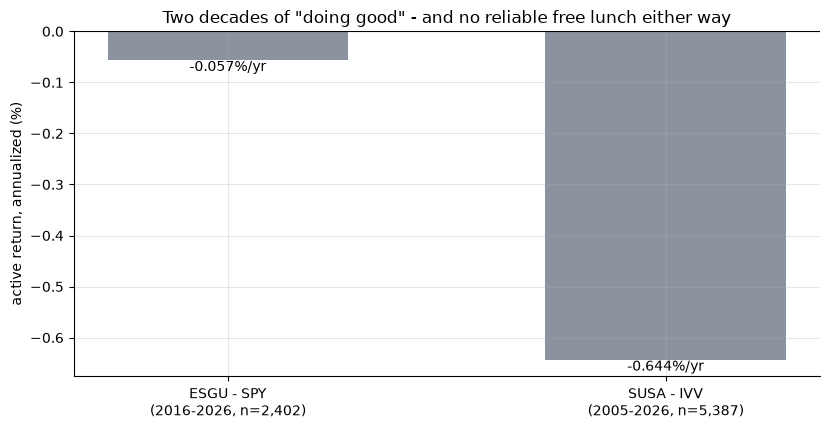

ESGU-SPY -0.057%/yr   SUSA-IVV -0.644%/yr


In [2]:
if HAVE_REAL:
    e_active = R['esgu_active_ann']
    s_active = R['susa_active_ann']
else:
    e_active, s_active = R['esgu_active_ann'], R['susa_active_ann']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['ESGU - SPY\n(2016-2026, n=2,402)','SUSA - IVV\n(2005-2026, n=5,387)'],
       [e_active, s_active], color=[GREY, GREY], width=.55)
for i,v in enumerate([e_active, s_active]): ax.annotate(f'{v:+.3f}%/yr',(i,v),
    ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('active return, annualized (%)')
ax.set_title('Two decades of "doing good" - and no reliable free lunch either way')
plt.tight_layout(); plt.show()
print(f'ESGU-SPY {e_active:+.3f}%/yr   SUSA-IVV {s_active:+.3f}%/yr')

Both bars sit near zero. ESGU trailed SPY by **0.06%** a year; SUSA trailed IVV by **0.64%**. Neither is a big number, and — the quants notebook shows — neither survives a proper significance test. **No premium, no clear penalty.**

**Next, the price of admission.** ESG funds aren't free — they charge more, explicitly, in the prospectus:

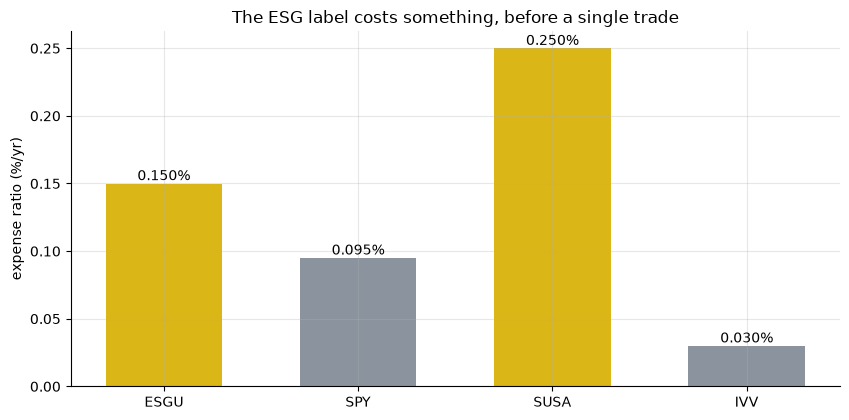

ESGU +0.055%/yr vs SPY, SUSA +0.220%/yr vs IVV


In [3]:
fig, ax = plt.subplots(figsize=(8.6, 4.3))
pairs = [('ESGU', R['er_esgu'], 'SPY', R['er_spy']),
         ('SUSA', R['er_susa'], 'IVV', R['er_ivv'])]
labels, vals, cols = [], [], []
for fn, fv, bn, bv in pairs:
    labels += [fn, bn]; vals += [fv, bv]; cols += [AMBER, GREY]
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('expense ratio (%/yr)')
ax.set_title('The ESG label costs something, before a single trade')
plt.tight_layout(); plt.show()
print(f"ESGU +{R['er_gap_esgu']:.3f}%/yr vs SPY, SUSA +{R['er_gap_susa']:.3f}%/yr vs IVV")

ESGU costs **0.055%/yr** more than SPY; SUSA costs **0.220%/yr** more than IVV. This is a documented fact — a prospectus number, not a fitted one — and it's already baked into the price series above; it's the *structural* reason the active return leans negative rather than sitting at an exact zero.

**Finally, the unmasking.** If ESGU or SUSA *did* show a real gap, would it survive controlling for an obvious growth/quality tilt?

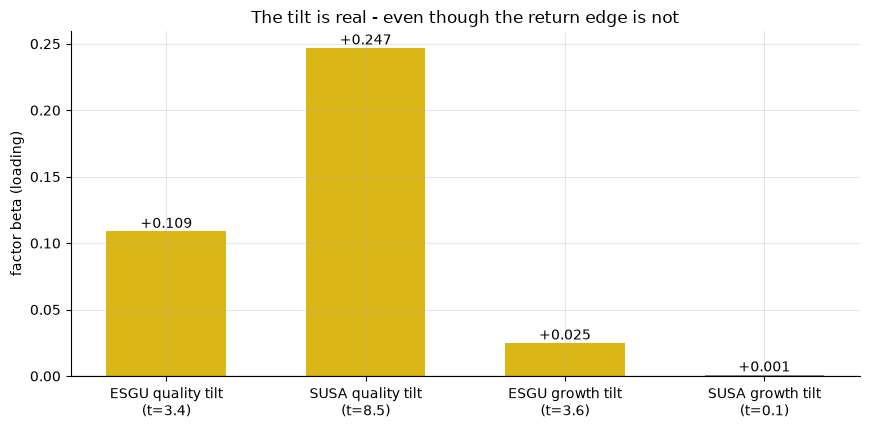

quality betas: 0.109 0.247
growth-value betas: 0.025 0.001


In [4]:
fig, ax = plt.subplots(figsize=(8.8, 4.4))
labels = ['ESGU quality tilt\n(t={:.1f})'.format(R['esgu_beta_q_t']),
          'SUSA quality tilt\n(t={:.1f})'.format(R['susa_beta_q_t']),
          'ESGU growth tilt\n(t={:.1f})'.format(R['esgu_beta_gv_t']),
          'SUSA growth tilt\n(t={:.1f})'.format(R['susa_beta_gv_t'])]
vals = [R['esgu_beta_q'], R['susa_beta_q'], R['esgu_beta_gv'], R['susa_beta_gv']]
cols = [AMBER if abs(t) >= 2 else GREY for t in
        [R['esgu_beta_q_t'], R['susa_beta_q_t'], R['esgu_beta_gv_t'], R['susa_beta_gv_t']]]
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.3f}',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('factor beta (loading)')
ax.set_title('The tilt is real - even though the return edge is not')
plt.tight_layout(); plt.show()
print('quality betas:', R['esgu_beta_q'], R['susa_beta_q'])
print('growth-value betas:', R['esgu_beta_gv'], R['susa_beta_gv'])

Both ESG funds carry a **statistically real quality tilt** (amber bars — *t* = 3.4 and 8.5), and ESGU carries a small but real growth tilt too (*t* = 3.6). That's the mechanism working exactly as the skeptics describe: exclude fossil fuels and tobacco, and you mechanically end up in better-capitalized, more tech-heavy names. But because there was **no significant return gap to begin with**, there's no alpha for the tilt to "explain away" — the tilt is just... the portfolio you actually hold.

## 5 · The verdict

- **Signal — None.** Neither ESG fund beats (or loses to) its plain benchmark by a statistically real amount, across 9.5 and 21.4 years of daily data.
- **Tradability — Mirage.** There's no edge to trade, and the ESG label carries a real fee and real tracking error for nothing in expected return.
- **"Any gap is just a growth/quality tilt?" — Confirmed.** The tilt is real and measurable; it just doesn't come with a return edge attached, positive or negative.

## 6 · Going further 🚪

- **The real ESG question may not be about return at all.** If ESG investing is worth doing, the honest case is values-alignment and stewardship — not a promised return edge this tape can't find.
- **International and small-cap ESG funds** may show a different picture (a less mature market, thinner benchmarks) — this study only tests the flagship US large-cap products.
- **Sibling studies:** [211-sin-stocks](../../211-sin-stocks/) tests the mirror claim (do *excluded* stocks outperform?) with individual tickers — see [docs/references.md](docs/references.md) for the full dedup map.

*Think an ESG fund's factor loadings hide something this two-factor model misses? Show a growth/quality-controlled alpha that clears t = 2 — then we'll talk.*